# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [5]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (500, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id         0
age             0
churn_date    462
city            0
first_name      0
last_name       0
reg_date        0
tariff          0
dtype: int64
user_id       0.000
age           0.000
churn_date    0.924
city          0.000
first_name    0.000
last_name     0.000
reg_date      0.000
tariff        0.000
dtype: float64


In [11]:
# cantidad de nulos para usage

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
- La columna churn_date tiene 462 nulos, que es la fecha de abandono, muy importante para el analisis. Lo recomendado es imputar estos valores para no perder la informacion.
- Significa que el 92.4% de los clientes siguen activos, lo que es muy bueno.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users

users['age'].mean()

46.588

- La columna `user_id` ... Hay 500 usuarios.
- La columna `age` ... La edad promedio es 46.5 años.

In [13]:
# explorar columnas numéricas de usage
usage['user_id'].count()

40000

- Las columnas `id` y `user_id`...La columna id y user_id tienen 40.000 registros.


In [14]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']
print(users['city'].value_counts())


Москва             99
Санкт-Петербург    39
Новосибирск        16
Омск               14
Казань             14
                   ..
Химки               1
Иваново             1
Архангельск         1
Нижневартовск       1
Подольск            1
Name: city, Length: 76, dtype: int64


- La columna `city` Hay 76 ciudades
- La columna `plan` Solo hay 2 planes

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` Tiene 22.092 registros de texto y 17.908 registros de llamadas.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En churn_date pero es un buen dato, porque significa que no han abandonado.
- ¿Qué acción tomarías?
  Los mantengo.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].head()
users['reg_date'].isna().sum()


0

En `reg_date`, se ve que la fecha quedo bien y son del año 2018 y no hay nulos.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].head()
usage['date'].isna().sum()


50

En `date`, ... son fechas del año 2024 y estan en formato correcto. 
Basaremos el análisis en estas fechas y hay 50 fechas nulas.


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- En reg_date las fechas estan consistentes y no hay nulos.
- En date las fechas estan consistentes pero hay 50 nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age

users['age'] = pd.to_numeric(users['age'], errors='coerce')
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    500.00000
mean      46.58800
std       16.66763
min       18.00000
25%       32.00000
50%       46.00000
75%       62.00000
max       75.00000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)
print("Nulos en 'city':", users['city'].isna().sum())
print("\nFrecuencia de valores (incluyendo nulos):")
print(users['city'].value_counts(dropna=False).head(10))


Nulos en 'city': 0

Frecuencia de valores (incluyendo nulos):
Москва              99
Санкт-Петербург     39
Новосибирск         16
Омск                14
Казань              14
Уфа                 12
Ульяновск           11
Краснодар           11
Екатеринбург        11
Набережные Челны    11
Name: city, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users.loc[users['reg_date'] > pd.Timestamp.now(), 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64



La proporción de valores nulos en `duration` y `length` presenta dependencia estructural respecto a las categorías de la variable type. Al estar condicionada por datos observados, la pérdida se clasifica como Missing At Random (MAR).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
''''user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)'''''
users['user_id'] = pd.to_numeric(users['user_id'], errors='coerce')
usage_agg['user_id'] = pd.to_numeric(usage_agg['user_id'], errors='coerce')

# Match directo
match0 = users['user_id'].isin(usage_agg['user_id']).mean()
print(f"Match directo: {match0*100:.2f}%")

# Si es 0%, ajustar por offset (en tu ejemplo es 9000)
if match0 == 0:
    offset = usage_agg['user_id'].min() - users['user_id'].min()
    usage_agg['user_id'] = usage_agg['user_id'] - offset
    print(f"Se ajustó usage_agg.user_id restando offset = {offset}")

# Merge igual que tu estructura original
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head()


Match directo: 0.00%
Se ajustó usage_agg.user_id restando offset = 9000


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,7,3,23.70
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,5,10,33.18
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,5,2,10.74
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,11,3,8.99
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,500.000000,500.00000,500.000000,500.000000,500.000000
mean,1249.500000,46.58800,5.558000,4.460000,23.935660
std,144.481833,16.66763,2.383695,2.176666,21.382111
min,1000.000000,18.00000,0.000000,0.000000,0.000000
25%,1124.750000,32.00000,4.000000,3.000000,11.047500
50%,1249.500000,46.00000,5.000000,4.000000,19.975000
75%,1374.250000,62.00000,7.000000,6.000000,31.000000
max,1499.000000,75.00000,13.000000,12.000000,155.420000


In [29]:
# Distribución porcentual del tipo de plan
print(user_profile['tariff'].value_counts(normalize=True) * 100)

smart    70.2
ultra    29.8
Name: tariff, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

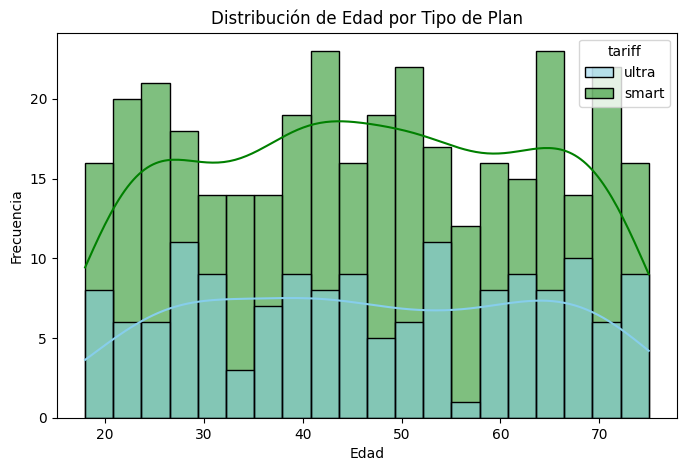

In [30]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 5))
sns.histplot(data=user_profile, x='age', hue='tariff', palette=['skyblue', 'green'], kde=True, bins=20)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

- Distribución: Uniforme y multimodal para ambos planes. No presenta un sesgo (asimetría) evidente hacia la izquierda o la derecha. El rango operativo abarca la totalidad del espectro demográfico adulto, aproximadamente desde los 18 hasta los 75 años.

- Patrón: La variable edad no es un factor discriminante fuerte para la elección del plan. El plan 'smart' registra una frecuencia absoluta significativamente mayor en todos los rangos de edad (alcanzando picos de ~23 usuarios por bin), frente al plan 'ultra' (con picos máximos en torno a ~11 usuarios por bin). La proporción de adopción entre 'smart' y 'ultra' se mantiene relativamente constante a lo largo de toda la distribución."

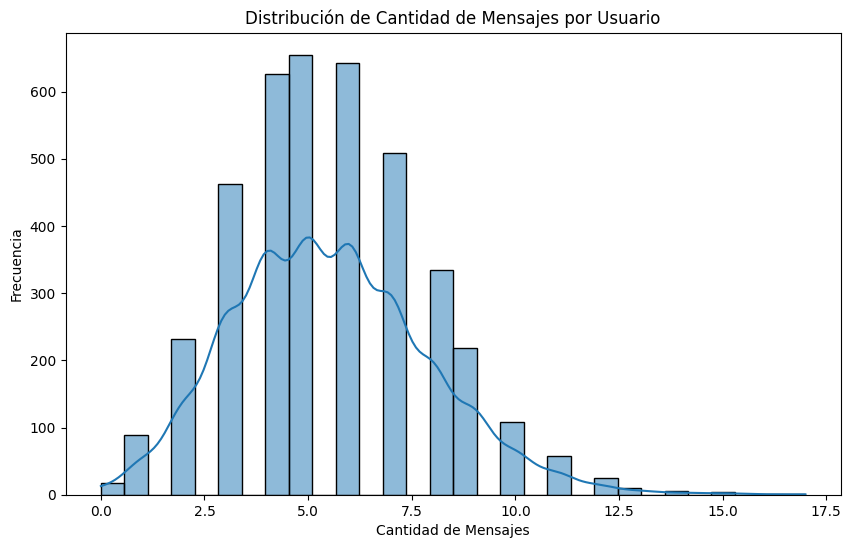

In [31]:
# Histograma para visualizar la cant_mensajes


plt.figure(figsize=(10, 6))
sns.histplot(data=usage_agg, x='cant_mensajes', bins=30, kde=True)
plt.title('Distribución de Cantidad de Mensajes por Usuario')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

#Distribución: Asimétrica positiva (sesgada a la derecha).

#Patrón: La volumetría indica que el grueso de la base de clientes concentra su actividad entre los 3 y 8 mensajes, con la moda (mayor frecuencia de usuarios) situada entre los 4 y 6 mensajes. La adopción decae de forma progresiva a partir de los 10 mensajes, presentando una cola (valores atípicos o usuarios intensivos) que se extiende hasta un máximo de ~17 mensajes.


💡Insights:
- Distribución: Asimétrica positiva (sesgada a la derecha).

- Patrón: La volumetría indica que el grueso de la base de clientes concentra su actividad entre los 3 y 8 mensajes, con la moda (mayor frecuencia de usuarios) situada entre los 4 y 6 mensajes. La adopción decae de forma progresiva a partir de los 10 mensajes, presentando una cola (valores atípicos o usuarios intensivos) que se extiende hasta un máximo de ~17 mensajes.


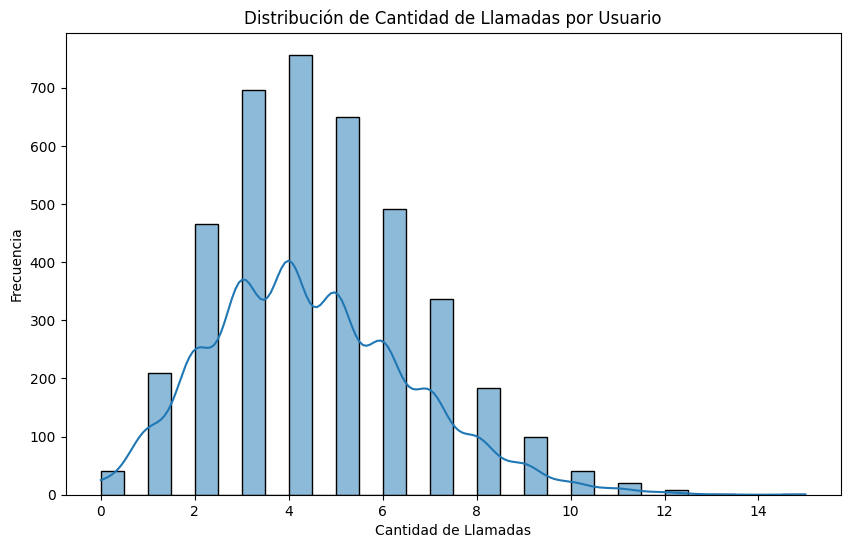

In [32]:
    # Histograma para visualizar la cant_llamadas


plt.figure(figsize=(10, 6))
sns.histplot(data=usage_agg, x='cant_llamadas', bins=30, kde=True)
plt.title('Distribución de Cantidad de Llamadas por Usuario')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- Distribución: Asimétrica positiva (sesgada a la derecha).

- Patrón: La mayor concentración de actividad se agrupa en el rango de 2 a 6 llamadas. La moda se sitúa exactamente en 4 llamadas por usuario, registrando el pico máximo de frecuencia (superando las 700 observaciones). A partir de las 7 llamadas, la distribución decae de forma acentuada, presentando una cola que se extiende hasta un máximo operativo de 15 llamadas correspondientes a usuarios con consumo intensivo.

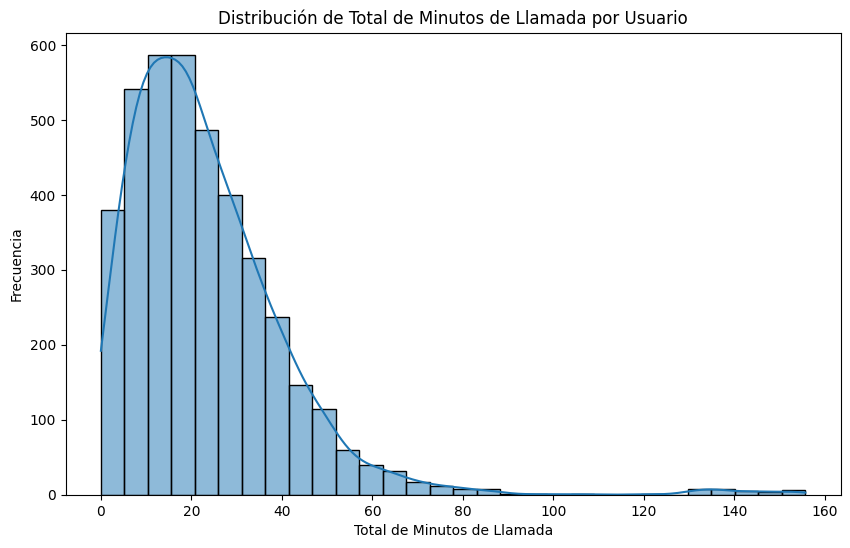

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=usage_agg, x='cant_minutos_llamada', bins=30, kde=True)
plt.title('Distribución de Total de Minutos de Llamada por Usuario')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.show()

💡**Insights:**
- Distribución: Asimétrica positiva (sesgada a la derecha).

- Patrón: La masa principal de datos se concentra en el rango inferior, con la moda (pico de frecuencia) ubicada entre los 10 y 20 minutos de uso. El volumen de usuarios decae de forma pronunciada a partir de los 40-50 minutos. La larga cola derecha evidencia la presencia de valores atípicos (outliers) que alcanzan hasta los ~160 minutos, representando a un segmento marginal de usuarios con consumo extremo.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

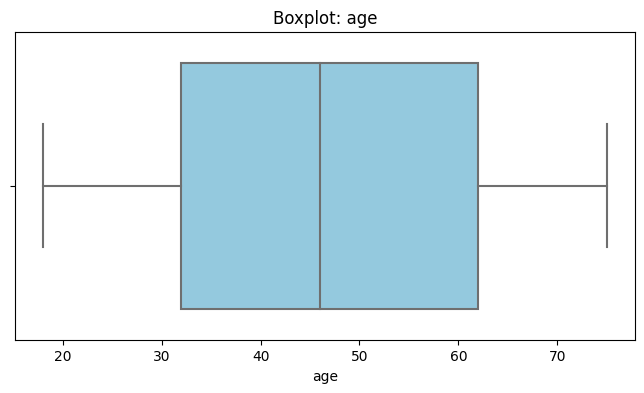

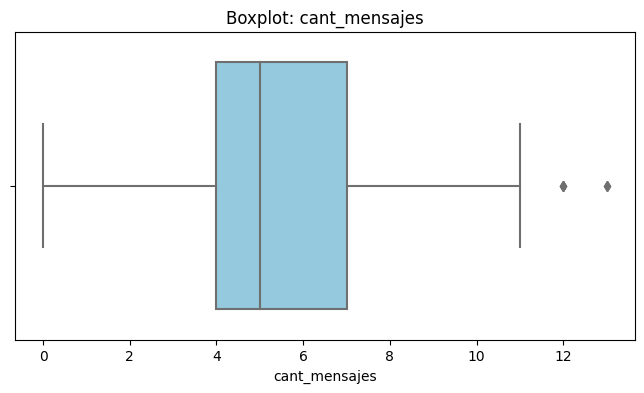

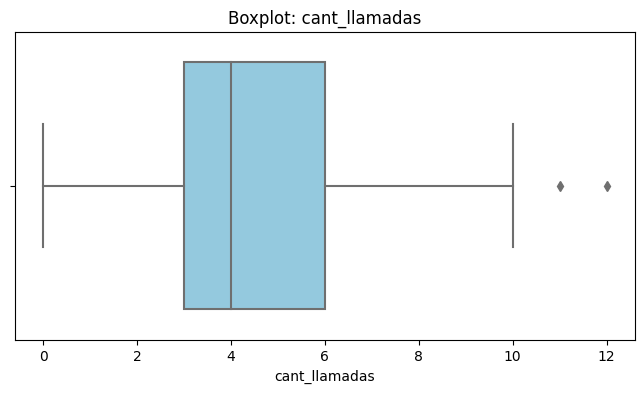

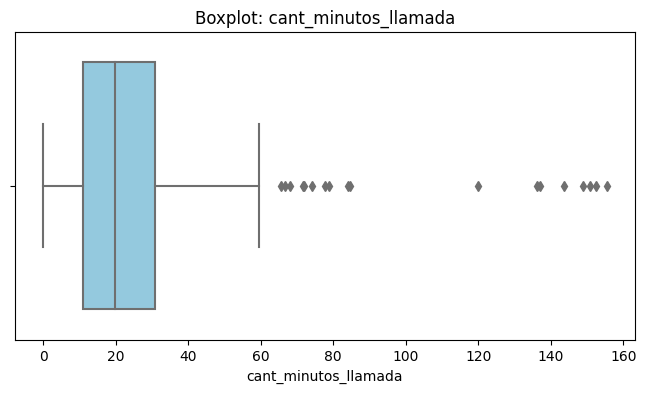

In [34]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers. La distribución es acotada y uniforme dentro de rangos demográficos normales (ej. 18-75 años).
- cant_mensajes: La mayoría de usuarios envía entre 4 y 7 mensajes (mediana ≈ 5), con valores “normales” hasta ~11.
Hay outliers altos (≈12–13 mensajes) que representan usuarios mucho más activos que el promedio (posibles power users).
- cant_llamadas: La mayoría de usuarios realiza entre 3 y 6 llamadas (mediana ≈ 4), con valores “normales” hasta ~10.
Aparecen outliers altos (≈11–12 llamadas) que representan usuarios con actividad de llamadas significativamente mayor al resto.
- cant_minutos_llamada: La mayoría de usuarios acumula ~10 a 30 minutos de llamada (mediana ≈ 20–22), con valores “normales” hasta ~60. Hay muchos outliers altos (≈65 hasta ~155 min), indicando un grupo de usuarios que habla muchísimo más que el promedio (sesgo fuerte a la derecha).

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']  # ajusta nombres si aplica

limites = []

for col in columnas_limites:
    s = pd.to_numeric(user_profile[col], errors='coerce').dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    limites.append({
        'columna': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'lim_inf': lim_inf,
        'lim_sup': lim_sup,
        'outliers_n': int(((s < lim_inf) | (s > lim_sup)).sum())
    })

limites_df = pd.DataFrame(limites)
limites_df



,columna,Q1,Q3,IQR,lim_inf,lim_sup,outliers_n
0,cant_mensajes,4.0000,7.0,3.0000,-0.50000,11.50000,5
1,cant_llamadas,3.0000,6.0,3.0000,-1.50000,10.50000,2
2,cant_minutos_llamada,11.0475,31.0,19.9525,-18.88125,60.92875,18


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,500.000000,500.000000,500.000000
mean,5.558000,4.460000,23.935660
std,2.383695,2.176666,21.382111
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.047500
50%,5.000000,4.000000,19.975000
75%,7.000000,6.000000,31.000000
max,13.000000,12.000000,155.420000


💡**Insights:** 
- cant_mensajes: (Q1=4, Q3=7 → lim sup ≈ 11.5; max=13): Mantener. Los “outliers” (12–13) están muy cerca del límite y probablemente son power users reales; quitarlos te haría perder señal de alto engagement.
- cant_llamadas: (Q1=3, Q3=6 → lim sup ≈ 10.5; max=12): Mantener. Son pocos casos (11–12) y representan usuarios con mayor uso de llamadas; eliminarlos sesga el análisis hacia usuarios promedio.
- cant_minutos_llamada: Q1≈11.05, Q3=31 → lim sup ≈ 60.93; max=155.42): Mantener. Aquí los outliers son más extremos y pueden dominar promedios/modelos, pero pueden ser usuarios legítimos de alto consumo (valiosos para segmentación).

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
import numpy as np
import pandas as pd
# Asegurar que sean numéricas
user_profile['cant_llamadas'] = pd.to_numeric(user_profile['cant_llamadas'], errors='coerce')
user_profile['cant_mensajes'] = pd.to_numeric(user_profile['cant_mensajes'], errors='coerce')


# Crear la columna grupo_uso según reglas dadas
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

# Ver distribución
user_profile['grupo_uso'].value_counts()


Uso medio    370
Bajo uso      92
Alto uso      38
Name: grupo_uso, dtype: int64

In [38]:
# verificar cambios

user_profile.head()


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,7,3,23.70,Uso medio
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,5,10,33.18,Alto uso
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,5,2,10.74,Uso medio
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,11,3,8.99,Alto uso
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
user_profile['age'] = pd.to_numeric(user_profile['age'], errors='coerce')

# Crear la columna grupo_edad según reglas dadas
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

# Ver distribución
user_profile['grupo_edad'].value_counts()

Adulto          254
Adulto Mayor    140
Joven           106
Name: grupo_edad, dtype: int64

In [40]:
# verificar cambios
user_profile.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,7,3,23.70,Uso medio,Adulto
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,5,10,33.18,Alto uso,Adulto
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,5,2,10.74,Uso medio,Adulto
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,11,3,8.99,Alto uso,Joven
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

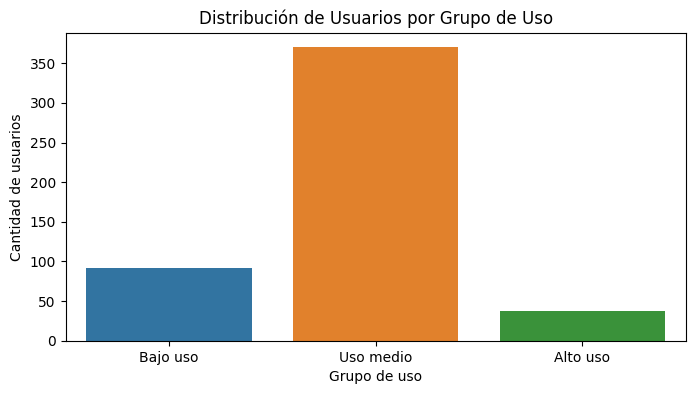

In [41]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

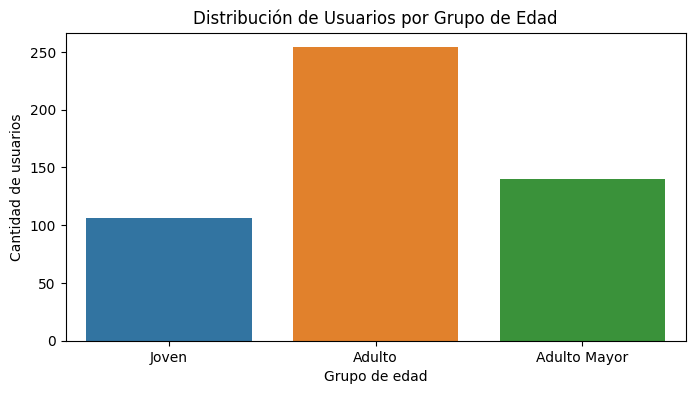

In [42]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
  - users.user_id venía como 1000, 1001... mientras usage_agg.user_id venía como 10000, 10001... (offset = 9000).
  - En este tipo de datasets es común que IDs o métricas lleguen como texto ("1.0", espacios, etc.). Por eso fue clave forzar to_numeric en columnas de uso antes de segmentar o calcular IQR.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
  - Segmentación por uso (grupo_uso)
    - Bajo uso: llamadas < 5 y mensajes < 5
    - Uso medio: llamadas < 10 y mensajes < 10
    - Alto uso: el resto (usuarios con actividad superior o combinaciones altas)
  - Segmentación por edad (grupo_edad)
    - Joven: age < 30
    - Adulto: age < 60
    - Adulto Mayor: ≥ 60
  - Lectura de negocio (cómo se comportan)
    Esta doble segmentación permite ver quién usa más (grupo_uso) y qué perfil etario lo concentra (grupo_edad).
  - En general, Alto uso tiende a concentrar usuarios con mayor necesidad del servicio (comunicación frecuente o prolongada), mientras Bajo uso puede ser prepago / esporádico / sensible a precio.
  - El cruce (grupo_edad × grupo_uso) es el que se vuelve accionable: te muestra dónde conviene retener, upsell y diseñar planes. /n

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  - **Más valiosos (prioridad alta)**
    - Alto uso (independiente de edad):Tiene mayor consumo → mayor potencial de ARPU (ingreso por usuario) y margen si el plan está bien diseñado. Son candidatos naturales para planes premium, bundles, add-ons y fidelización.
  - Uso medio (alto volumen usualmente): Suele ser el “core” de la base: buen balance entre volumen y estabilidad. Gran oportunidad de upsell con incentivos (más minutos/mensajes/datos) sin subir demasiado el precio.
  - **Menos valioso (pero estratégico)**
     - Bajo uso: menor ARPU, pero útil para adquisición y prevención de churn con planes sencillos/low-cost.
       
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
  - cant_mensajes: outliers_n = 2 (límite superior ≈ 11.5, max=13) ➜ Pocos “power users” de mensajería. Implica usuarios de alta interacción (posibles heavy users reales o casos especiales).

  - cant_llamadas: outliers_n = 5 (límite superior ≈ 10.5, max=12) ➜ Un grupo pequeño hace muchas llamadas. Puede ser un nicho que valora paquetes de llamadas o beneficios por frecuencia.

  - cant_minutos_llamada: outliers_n = 29 (límite superior ≈ 60.93, max≈155.42) ➜ Aquí el patrón extremo es mucho más marcado: existe un grupo relevante que consume muchísimos minutos.
 
  - **Implicación clave: estos usuarios pueden estar “sub-atendidos” por los planes actuales (pagan de más, o se quedan cortos y generan fricción), o son el target ideal para un plan “ilimitado”/alto volumen.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

   - **A) Diseñar un portafolio por segmentos (3 niveles claros)**

    - Plan Básico (Bajo uso)
   Precio bajo, beneficios mínimos (mensajes/llamadas limitadas)
   Objetivo: adquisición + evitar churn por precio.

     - Plan Balance (Uso medio)
   Beneficios equilibrados, buen “value for money”
   Objetivo: maximizar base y subir conversión desde bajo uso (upsell).

     - Plan Pro / Alto Consumo (Alto uso)
   Pensado especialmente para el hallazgo fuerte: minutos altos
   Opciones: paquetes grandes de minutos, rollover, o “ilimitado” con fair use
   Objetivo: capturar ARPU alto y fidelizar.

  - **B) Add-ons inteligentes (upsell sin cambiar plan)**
   Bolsa de minutos extra (para los outliers de minutos)
   Pack de llamadas frecuentes (para outliers de llamadas)
   Beneficios de fidelidad para alto uso (descuentos por permanencia, prioridad de atención)

  - **C) Gestión de outliers para estrategia**
   No los elimines del análisis: son señal de mercado.
   Trátalos analíticamente (winsorización/log) solo si vas a modelar, pero a nivel negocio: son candidatos premium.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- El user_id estaba desalineado entre users (1000…) y usage_agg (10000…), causando 0% match en el merge y dejando 100% NaN en cant_mensajes, cant_llamadas y cant_minutos_llamada (por eso las gráficas salían en blanco).

- Tras corregir el desfase (offset = 9000), el cruce quedó en 100% match, habilitando correctamente el análisis de uso, outliers y segmentación.


🔍 **Segmentos por Edad**
- Se clasificaron usuarios en Joven (<30), Adulto (<60) y Adulto Mayor (≥60) para entender diferencias de adopción y necesidades por etapa de vida.

- Esta segmentación permite cruzar edad con uso para identificar grupos con mayor potencial de retención, upsell o planes específicos.


📊 **Segmentos por Nivel de Uso**
- Se definieron tres grupos: Bajo uso (llamadas<5 y mensajes<5), Uso medio (llamadas<10 y mensajes<10) y Alto uso (resto).

- Los outliers muestran que, aunque mensajes y llamadas tienen pocos extremos, minutos de llamada presenta muchos outliers altos, indicando un grupo relevante de alto consumo.


➡️ Existe un segmento claro de usuarios intensivos en minutos, potencialmente el más valioso para monetización (mayor ARPU) y para diseñar planes “pro”.

La base se puede optimizar con un portafolio escalonado (bajo/medio/alto) y add-ons, evitando que los heavy users queden sub-atendidos o se vayan por precio/beneficio.


💡 **Recomendaciones**
- Crear/ajustar planes en 3 niveles: Básico (bajo uso), Balance (uso medio) y Pro/Alto consumo (alto uso, enfocado en minutos), con límites y beneficios claros.

- Implementar add-ons (bolsa de minutos, paquetes de llamadas) y estrategias de retención para usuarios de alto consumo; mantener outliers en el análisis porque representan power users y oportunidades comerciales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`